In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("ABS Tech Case 2026_Data.xlsx")
df["HispanicLatino"] = df["HispanicLatino"].str.capitalize()

## Defining the talent formula

In [19]:
talent_dict = {
    "Technical score": {
        "Current ability": 0.15,
        "Training hours": 0.10,
        "Innovative contributions": 0.10,
        "Contribution to special projects": 0.10,
        "AI use": 0.025,
        "AI confidence": 0.025,
    },
    "Personal score": {
        "Performance": 0.10,
        "Engagement": 0.05,
        "Work-life balance": 0.05,
        "Job stress": 0.05,
    },
    "Interpersonal score": {
        "Feedback and collaboration": 0.10,
        "Teamwork": 0.05,
        "Networking": 0.05,
        "Colleague assessment": 0.05,

    },
}


df["technical_score"] = (
    talent_dict["Technical score"]["Current ability"] * df["TechLev"] +
    talent_dict["Technical score"]["Training hours"] * df["TrainHours"] +
    talent_dict["Technical score"]["AI use"] * df["AIUse"] +
    talent_dict["Technical score"]["AI confidence"] * df["AIConf"] +
    talent_dict["Technical score"]["Innovative contributions"] * df["InnoCont"] +
    talent_dict["Technical score"]["Contribution to special projects"] * df["SpecialProjectsCount"]
)

df["personal_score"] = (
    talent_dict["Personal score"]["Engagement"] * df["EngagementSurvey"] +
    talent_dict["Personal score"]["Work-life balance"] * df["WLF"] +
    talent_dict["Personal score"]["Performance"] * df["PerfScore"] +
    talent_dict["Personal score"]["Job stress"] * df["JobStr"]
)

df["interpersonal_score"] = (
    talent_dict["Interpersonal score"]["Feedback and collaboration"] * (df["Feedback"] + df["Trust"]) / 2 +
    talent_dict["Interpersonal score"]["Teamwork"] * df["TeamIden"] +
    talent_dict["Interpersonal score"]["Networking"] * df["Network"] +
    talent_dict["Interpersonal score"]["Colleague assessment"] * df["ProjColl"]
)

df["talent_score"] = (
    0.50 * df["technical_score"] +
    0.25 * df["personal_score"] +
    0.25 * df["interpersonal_score"]
)


threshold = df["talent_score"].quantile(0.80)       # Changeable
df["is_talent"] = (df["talent_score"] >= threshold).astype(int)

## Visualising talent

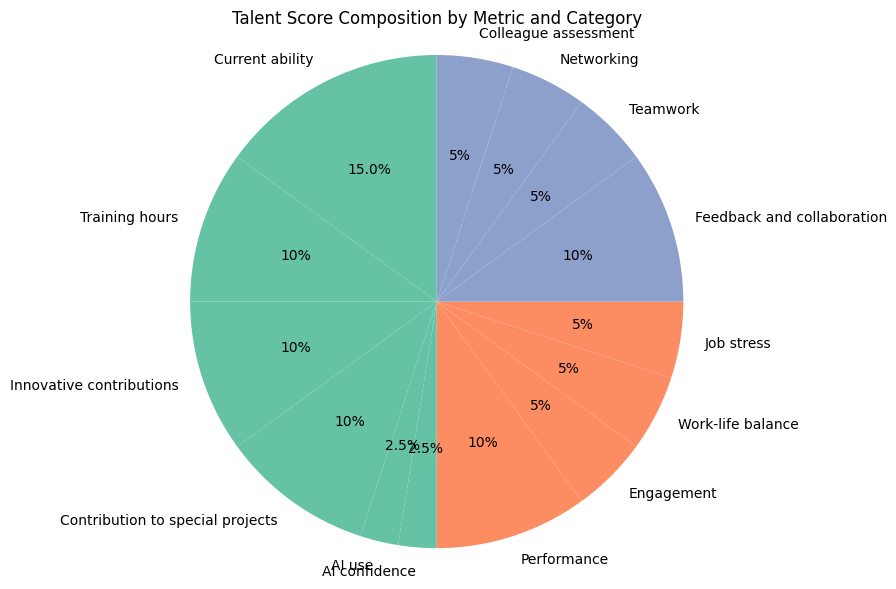

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def autopct_fmt(pct):
    if pct.is_integer():
        return f"{int(pct)}%"
    else:
        return f"{pct:.1f}%"

labels = []
sizes = []
colors = []

palette = sns.color_palette("Set2")
color_map = {
    "Technical score": palette[0],
    "Personal score": palette[1],
    "Interpersonal score": palette[2],
}

for category, metrics in talent_dict.items():
    for metric, value in metrics.items():
        labels.append(metric)
        sizes.append(value)
        colors.append(color_map[category])

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=autopct_fmt,
    startangle=90
)

plt.title("Talent Score Composition by Metric and Category")
plt.axis("equal")
plt.show()